In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict ,Annotated,Literal
from dotenv import load_dotenv
import os
from pydantic import BaseModel ,Field 
import operator
from langchain_core.messages import SystemMessage, HumanMessage
    

#### here we have 3 differnt llm based on the our taget and work like the i want to writing the post then have llm which is best in generation like that in the evulation we have llm like which is best in the evulation but here we have the dummy project so we used only one llm

In [3]:
load_dotenv()

True

In [4]:
api_key = os.getenv('GOOGLE_API_KEY')

In [5]:
Generator_model = ChatGoogleGenerativeAI(
    model='gemini-2.0-flash',
    google_api_key = api_key
)

Evulator_model = ChatGoogleGenerativeAI(
    model='gemini-2.0-flash',
    google_api_key = api_key
)

Optimizer_model = ChatGoogleGenerativeAI(
    model='gemini-2.0-flash',
    google_api_key = api_key
)

In [6]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [7]:
structured_evaluator_llm = Evulator_model.with_structured_output(TweetEvaluation)

In [8]:
# State
class TweetState(TypedDict):
    topic: str
    tweet : str
    evaluation : Literal["approved","needs_improvement"]
    feedback : str
    iteration : int
    max_iteration : int

In [9]:
def generate_tweet(state:TweetState) -> TweetState:
    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = Generator_model.invoke(messages).content

    return {'tweet':response}

def evaluate_tweet(state:TweetState) -> TweetState:
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality - Is this fresh, or have you seen it a hundred times before?  
2. Humor - Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness - Is it short, sharp, and scroll-stopping?  
4. Virality Potential - Would people retweet or share it?  
5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    response = structured_evaluator_llm.invoke(messages)
    return {'evaluation':response.evaluation,'feedback':response.feedback}


In [10]:
def optimize_tweet(state:TweetState) -> TweetState:
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    response = Optimizer_model.invoke(messages)
    iteration = state['iteration'] + 1
    return {'tweet':response,'iteration':iteration}


In [11]:
def route_evalution(state:TweetState) -> TweetState:
    if state['evaluation'] == "approved" or state['iteration'] >= state['max_iteration']:
        return "approved"
    else:
        return "needs_improvement"

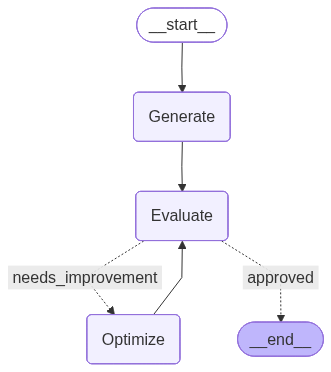

In [12]:
graph = StateGraph(TweetState)

graph.add_node("Generate",generate_tweet)
graph.add_node("Evaluate",evaluate_tweet)
graph.add_node("Optimize",optimize_tweet)

graph.add_edge(START,'Generate')
graph.add_edge('Generate', 'Evaluate')
graph.add_conditional_edges('Evaluate',route_evalution,{'approved':END,"needs_improvement":"Optimize"})
graph.add_edge('Optimize', 'Evaluate')

workflow = graph.compile()
workflow

In [13]:
initial_state = {
    "topic": "indian Railway",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 24.462020624s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [ ]:
result